# **Módulo 4: Avaliação de Modelos de Regressão**
---


Neste notebook, vamos aprofundar o conhecimento sobre **como medir a qualidade** dos modelos que criamos. Não basta apenas treinar o modelo; precisamos saber se ele é confiável, se generaliza bem para novos dados e onde ele está errando.

Abordaremos os três pilares da avaliação vistos na teoria:

-  **Métricas de Erro:** MAE, MSE, RMSE e $R^2$.
-  **Estratégia de Validação:** Train/Test Split e Validação Cruzada (Cross-Validation).
-  **Diagnóstico de Resíduos:** Análise visual dos erros para detectar padrões, heterocedasticidade e normalidade.

Utilizaremos o mesmo dataset `housing_tratado.csv` e o modelo de Regressão Linear do módulo anterior como base para nossas análises.


## **Configuração e Treinamento do Modelo Base**

Assim como no módulo anterior, começamos importando as bibliotecas e carregando nossos dados.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

In [3]:
url = "https://raw.githubusercontent.com/TreinamentoICCInatel/Curso_Regressao_na_Pratica/refs/heads/main/Arquivos/housing_tratado.csv"
housing = pd.read_csv(url)
housing.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity_<1H OCEAN,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN,median_house_value
0,-1.327835,1.052548,0.982143,-0.804819,-0.972476,-0.974429,-0.977033,2.344766,0.0,0.0,0.0,1.0,0.0,452600.0
1,-1.322844,1.043185,-0.607019,2.045890,1.357143,0.861439,1.669961,2.332238,0.0,0.0,0.0,1.0,0.0,358500.0
2,-1.332827,1.038503,1.856182,-0.535746,-0.827024,-0.820777,-0.843637,1.782699,0.0,0.0,0.0,1.0,0.0,352100.0
3,-1.337818,1.038503,1.856182,-0.624215,-0.719723,-0.766028,-0.733781,0.932968,0.0,0.0,0.0,1.0,0.0,341300.0
4,-1.337818,1.038503,1.856182,-0.462404,-0.612423,-0.759847,-0.629157,-0.012881,0.0,0.0,0.0,1.0,0.0,342200.0


Separar variável alvo (y) e variáveis explicativas (X)

In [4]:
X = housing.drop("median_house_value", axis=1)
y = housing["median_house_value"]

Nesta etapa, aplicaremos o `train_test_split` e o **modelo de regressão linear**, apresentados no módulo anterior, com o intuito de avaliá-los por meio dos métodos abordados neste módulo.

In [5]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print("Modelo treinado. Pronto para avaliação.")

Modelo treinado. Pronto para avaliação.


Aqui preparamos o terreno. O y_pred contém as "apostas" do modelo para o valor das casas, e o y_test contém os valores reais. A avaliação consiste em comparar esses dois.

# **Métricas de Avaliação Essenciais**

Primeiro vamos importar as métricas

In [6]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

### **MAE (Erro Médio Absoluto)**


Média dos erros absolutos: $|y_i-\hat{y}_i|$

Interpretação direta na unidade do alvo; menor MAE indica melhor ajuste.

In [7]:
mae = mean_absolute_error(y_test, y_pred)
print(f"MAE:  {mae:.2f}")

MAE:  50670.74


O MAE de **0.44** indica que, em média, o modelo erra aproximadamente 0.44 unidades da variável alvo em cada previsão.

### **MSE (Erro Quadrático Médio)**

Média dos erros ao quadrado:

$$MSE=\frac{1}{n}\sum_{i=1}^{n}(y_i-\hat{y}_i)^2$$


Penaliza muito erros grandes. Valores menores são melhores; um MSE alto indica presença de erros grandes.

In [8]:
mse = mean_squared_error(y_test, y_pred)
print(f"MSE:  {mse:.2f}")

MSE:  4908476721.16


O MSE de **0.37** representa a média dos erros elevados ao quadrado; ele serve para penalizar erros grandes, indicando o quão "punitivo" o modelo é com falhas graves.

### **RMSE (Raiz do MSE)**

Raiz quadrada do MSE. Retorna à mesma unidade do alvo, facilitando interpretação. Ainda penaliza outliers, mas dá a escala real do erro típico.

In [9]:
rmse = np.sqrt(mse)
print(f"RMSE: {rmse:.2f}")

RMSE: 70060.52


O RMSE de **0.61** indica o erro médio ponderado na mesma unidade da variável alvo, revelando que o modelo possui outliers que elevam o erro para além da média comum (MAE).

### **R² (Coeficiente de Determinação)**

Mede a proporção da variação dos dados explicada pelo modelo, varia geralmente entre 0 e 1 (quanto mais próximo de 1, melhor).

R² ≈ 0 indica que o modelo não explica a variação dos dados; valores negativos significam que o modelo é pior que prever a média.

In [10]:
r2 = r2_score(y_test, y_pred)
print(f"R²:   {r2:.3f}")

R²:   0.625


O R² de **0.625** indica que o modelo consegue explicar **62,5%** da variação total dos dados, mostrando o quanto ele foi capaz de aprender os padrões do dataset.

## **Validação Cruzada (Cross-Validation)**

Para ter uma estimativa mais robusta do desempenho, usamos a **Validação Cruzada (K-Fold).**

Dividiremos os dados em 5 partes (K=5). O modelo treinará em 4 e testará na 1 restante, repetindo o processo 5 vezes para garantir que o resultado não foi por "sorte" da divisão dos dados.

 Para isso uraremos o `cross_val_score`: função do scikit-learn que **automatiza K-Fold + avaliação**. O parâmetro scoring define a métrica. Aqui usaremos R².



In [11]:
from sklearn.model_selection import cross_val_score, KFold

# Definindo a estratégia de validação (5 folds)
kfold = KFold(n_splits=5, shuffle=True, random_state=42)

# Calculando o R2 médio
cv_r2_scores = cross_val_score(model, X, y, cv=kfold, scoring='r2')

Imprimindo os resultados

In [12]:
print("Resultados da Validação Cruzada (5 Folds):")
print(f"R2 em cada fold: {cv_r2_scores}")
print(f"R2 Médio:        {cv_r2_scores.mean():.4f} (+/- {cv_r2_scores.std():.4f})")

Resultados da Validação Cruzada (5 Folds):
R2 em cada fold: [0.62542406 0.65125577 0.64745741 0.67437515 0.61789986]
R2 Médio:        0.6433 (+/- 0.0201)


O R² Médio de 0.6433 confirma que o desempenho do modelo é consistente em diferentes partes do dataset, enquanto o desvio padrão de 0.0201 indica que o modelo é estável e não sofre grandes oscilações dependendo dos dados que recebe.

## **Diagnóstico de Resíduos**

Após treinar o modelo, analisamos os resíduos ($r_i = y_{real} - y_{pred}$), que são os erros (diferenças) de cada previsão. A análise gráfica dos resíduos ajuda a verificar suposições do modelo linear e identificar problemas:

In [13]:
import statsmodels.api as sm

# Calcular resíduos do conjunto de teste
residuals = y_test - y_pred

### **Resíduos vs Valores Previstos**

Um gráfico de dispersão com $x=\hat{y}_i$ e $y=r_i$.

 Idealmente, espera-se uma “nuvem” aleatória em torno de zero (linha horizontal), indicando homocedasticidade (variância constante) e ausência de padrões. Se os pontos mostrarem padrão (p.ex. curvatura, cones ou funis), pode haver modelagem incorreta ou variância não constante.

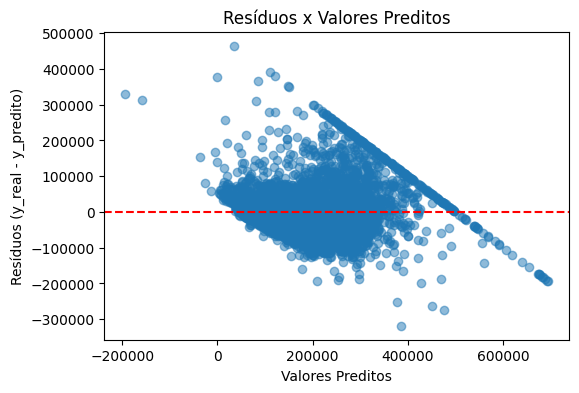

In [14]:
plt.figure(figsize=(6,4))
plt.scatter(y_pred, residuals, alpha=0.5)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Valores Preditos")
plt.ylabel("Resíduos (y_real - y_predito)")
plt.title("Resíduos x Valores Preditos")
plt.show()

Os resíduos se concentram em torno de $y=0$, indicando ausência de viés global relevante.
No entanto, a presença de um padrão visível e a variação não constante da dispersão dos resíduos sugerem heterocedasticidade e limitações do modelo em capturar toda a estrutura dos dados.

Assim, apesar das boas métricas globais, o diagnóstico indica que o modelo pode ser aprimorado.

### **Q-Q Plot (Normalidade)**

Verifica se os resíduos seguem distribuição normal. Plotamos quantis empíricos dos resíduos versus quantis teóricos de uma normal. Se os pontos se alinharem aproximadamente na linha de 45°, os resíduos são normalmente distribuídos (boa suposição para muitos testes estatísticos). Desvios estruturais ou caudas longas indicam assimetria ou outliers.

<Figure size 600x400 with 0 Axes>

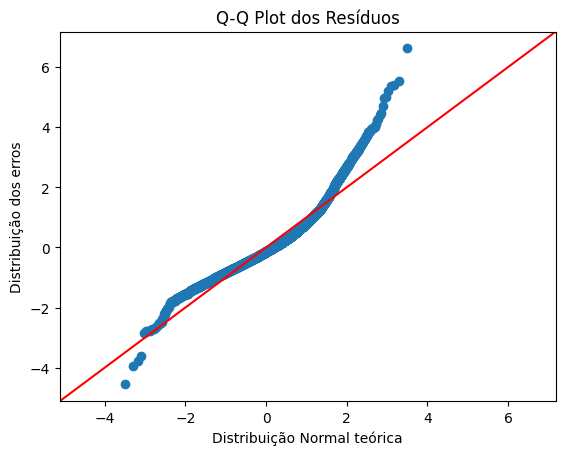

In [15]:
plt.figure(figsize=(6,4))
sm.qqplot(residuals, line='45', fit=True)
plt.title("Q-Q Plot dos Resíduos")
plt.xlabel("Distribuição Normal teórica")
plt.ylabel("Distribuição dos erros")
plt.show()

Os resíduos acompanham a linha apenas na região central, mas apresentam desvios nas extremidades, indicando que não seguem perfeitamente uma distribuição normal.

Isso sugere a presença de outliers e erros extremos, o que pode impactar análises estatísticas, embora não invalide o modelo para previsão.

### **Histograma dos Resíduos**

Mostra a distribuição dos erros. Deve ser aproximadamente em forma de sino centrado em zero. Caudas pesadas ou assimetria podem indicar erros sistemáticos (p.ex. modelo sempre subestima em valores altos).

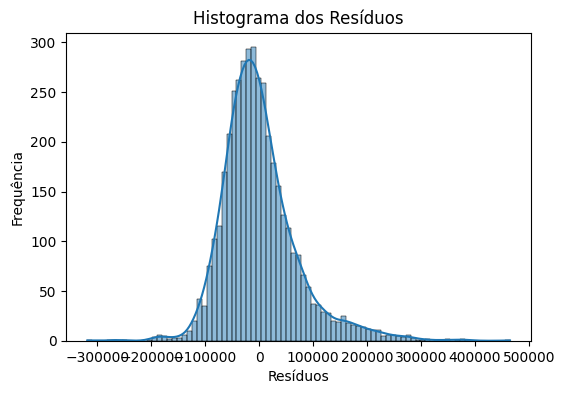

In [16]:
plt.figure(figsize=(6,4))
sns.histplot(residuals, kde=True)
plt.xlabel("Resíduos")
plt.ylabel("Frequência")
plt.title("Histograma dos Resíduos")
plt.show()

Os resíduos apresentam maior concentração em torno de zero, indicando que a maioria dos erros é pequena.

No entanto, observa-se assimetria e cauda à direita, sugerindo a presença de erros extremos positivos e desvios da normalidade ideal.

### **Outliers e Pontos Influentes**


Resíduos muito grandes (positivos ou negativos) indicam previsões bem distantes do real — potenciais outliers que merecem investigação.

Se um ponto extremo altera muito os coeficientes do modelo ao ser removido, é um ponto influente. Devemos investigar se são erros de medição ou casos especiais.

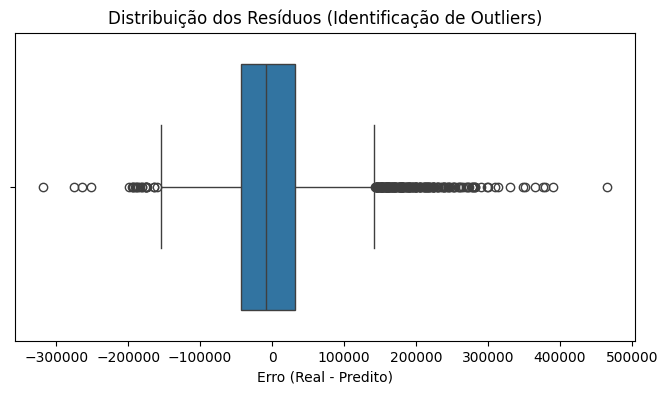

Número de casas com erro muito acima da média: 71


In [17]:
# 1. Visualização com Boxplot
plt.figure(figsize=(8, 4))
sns.boxplot(x=residuals)
plt.title('Distribuição dos Resíduos (Identificação de Outliers)')
plt.xlabel('Erro (Real - Predito)')
plt.show()

# 2. Identificando as linhas com os maiores erros
# Vamos considerar um erro "grave" qualquer um que seja maior que 3 desvios padrões
limite_outlier = 3 * residuals.std()
casas_com_erro_grave = X_test[abs(residuals) > limite_outlier]

print(f"Número de casas com erro muito acima da média: {len(casas_com_erro_grave)}")



O **boxplot dos resíduos** mostra como os erros do modelo estão distribuídos. A linha central indica o valor típico dos erros (mediana), enquanto a caixa representa onde está a maior parte deles. Os pontos que aparecem fora dessa região principal indicam casos atípicos, ou seja, previsões com erros muito maiores ou menores do que a maioria.

Neste gráfico, a presença de muitos pontos fora da região principal, tanto positivos quanto negativos, confirma que o modelo está cometendo erros extremos em algumas previsões.

A detecção de **71 casas com erros muito acima da média (acima de 3 desvios padrão)** e a visualização do boxplot com múltiplos outliers de resíduos sugerem fortemente que o tratamento dessas observações na etapa de pré-processamento pode ser crucial. Ignorar esses outliers pode enviesar o modelo, tornando-o menos preciso para dados que se desviam muito do padrão. Portanto, pode ser necessário voltar à etapa de tratamento de dados para investigar e decidir a melhor abordagem para lidar com esses pontos influentes, seja removendo-os, transformando-os ou utilizando modelos mais robustos a outliers.

---
Neste módulo, aprendemos a avaliar modelos de regressão de forma completa: usando métricas para medir o erro, validação para garantir confiabilidade e análise de resíduos para entender como o modelo erra. Essa combinação permite não apenas saber se o modelo é bom, mas também **por que** ele funciona (ou não), tornando a análise mais robusta e profissional.